# X5 Retail Analysis

## 1. О проекте и данных

**Почему динамика выручки Пятёрочки, Перекрёстка и Чижика в 2025 году различалась?**

Сравним масштаб сетей, продажи сопоставимых магазинов и расширение: эти различия задают разные вопросы для управления бизнесом.

Источник — [отчётность X5](https://www.x5.ru/en/investors/financial-and-operational-results/), Excel *Financial and Operating Results (RUB)*, лист `Operating Results`. Периоды: **«2024 Скорр.»** и **«2025 (2)»**.

В подготовленном CSV одна строка соответствует показателю за период. Выручка указана в **млн руб.**, площадь — в **тыс. кв. м**, магазины — в **штуках**. Анализ начинается с готового CSV, полученного из публичной отчётности X5; notebook выполняется из корня проекта.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

%matplotlib inline

palette = ["#2E86AB", "#5DAE8B", "#F4A261"]
plt.rcParams.update({
    "font.size": 11,
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

chains = ["Пятёрочка", "Перекрёсток", "Чижик"]
periods = ["2024 Скорр.", "2025 (2)"]
data = pd.read_csv("data/processed/x5_operating_results_long.csv")
data["Показатель"] = data["Показатель"].replace({
    "Пятёрочка (2)": "Пятёрочка",
    "Пятёрочка(2)": "Пятёрочка",
})
data["Раздел"] = data["Раздел"].str.replace(" (2)", "", regex=False)

## 2. Выручка: масштаб и темпы роста

Доля рассчитана в выручке **трёх выбранных сетей**. Сравним абсолютный прирост с темпом роста: большая сеть может расти медленнее в процентах, но добавлять больше выручки.

In [2]:
revenue = data[data["Раздел"].eq("Чистая розничная выручка (1)")]
revenue = revenue.pivot(index="Показатель", columns="Период", values="Значение")
revenue = revenue.loc[chains, periods].astype(int)
revenue.index.name = "Сеть"

growth = revenue.rename(columns={"2024 Скорр.": "2024", "2025 (2)": "2025"})
growth["Прирост"] = growth["2025"] - growth["2024"]
growth["Рост, %"] = (growth["2025"] / growth["2024"] - 1) * 100
growth["Доля, %"] = growth["2025"] / growth["2025"].sum() * 100

display(growth.style.format(precision=1, decimal=",", thousands=" "))

Период,2024,2025,Прирост,"Рост, %","Доля, %"
Сеть,,,,,
Пятёрочка,3 114 117,3 613 554,499 437,"16,0","79,2"
Перекрёсток,490 991,531 127,40 136,"8,2","11,6"
Чижик,249 501,417 500,167 999,"67,3","9,2"


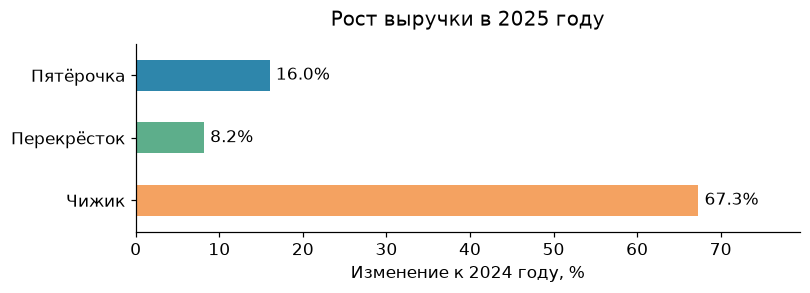

In [3]:
ax = growth["Рост, %"].plot(
    kind="barh", color=palette, figsize=(7.5, 2.8)
)
ax.invert_yaxis()
ax.set_title("Рост выручки в 2025 году", pad=12)
ax.set_xlabel("Изменение к 2024 году, %")
ax.set_ylabel("")
ax.set_xlim(0, growth["Рост, %"].max() * 1.18)
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=4)
plt.tight_layout()
plt.show()

Пятёрочка формирует **79,2%** выручки и даёт наибольший абсолютный прирост — **499 437 млн руб.** при росте на **16,0%**. Чижик лидирует по темпу (**67,3%**), но добавляет меньше — **167 999 млн руб.** Перекрёсток вырос на **8,2%**; размер исходной базы меняет оценку этих темпов.

## 3. LFL: продажи, трафик и средний чек

LFL показывает изменение сопоставимых магазинов в 2025 году к 2024 году. Переведём доли из CSV в проценты и посмотрим, как продажи менялись вместе с трафиком и чеком.

In [4]:
lfl = data[
    data["Раздел"].str.startswith("LFL - ")
    & data["Период"].eq("2025 (2)")
]
lfl = lfl.pivot(index="Раздел", columns="Показатель", values="Значение")
lfl = lfl.loc[
    [f"LFL - {chain}" for chain in chains],
    ["Продажи", "Трафик", "Средний чек"],
]
lfl.index = chains
lfl.index.name = "Сеть"
lfl.columns.name = None

lfl = lfl * 100
display(lfl.style.format(precision=1, decimal=","))

,Продажи,Трафик,Средний чек
Сеть,,,
Пятёрочка,"10,6","1,4","9,1"
Перекрёсток,"7,7","-2,2","10,1"
Чижик,"26,1","11,6","13,0"


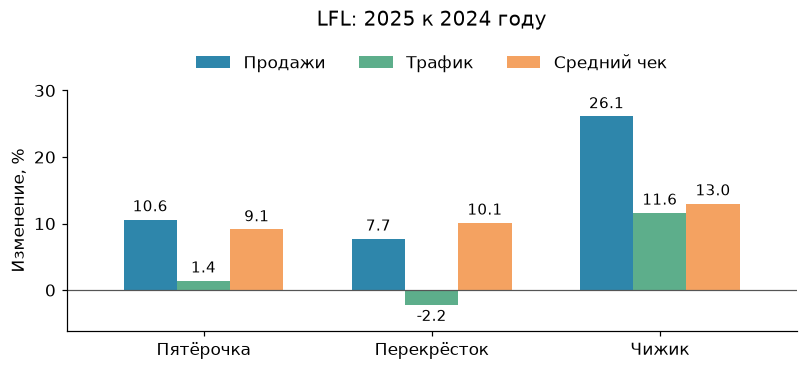

In [5]:
ax = lfl.plot(
    kind="bar", color=palette, figsize=(7.5, 3.5), rot=0, width=0.7
)
ax.set_title("LFL: 2025 к 2024 году", pad=42)
ax.set_xlabel("")
ax.set_ylabel("Изменение, %")
ax.axhline(0, color="#555555", linewidth=0.8)
ax.set_ylim(lfl.min().min() - 4, lfl.max().max() + 4)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.01), ncol=3, frameon=False)
for bars in ax.containers:
    ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=10)
plt.tight_layout()
plt.show()

У Пятёрочки и Чижика росли и трафик, и средний чек; LFL-продажи прибавили **10,6%** и **26,1%**. У Перекрёстка рост чека на **10,1%** компенсировал падение трафика на **2,2%**, а LFL-продажи выросли на **7,7%**. Причина снижения трафика в отчётности не раскрыта.

## 4. Расширение сетей и сравнение показателей

Сравним прирост магазинов и торговой площади между концом 2024 и 2025 годов.

In [6]:
stores = data[data["Раздел"].eq("Количество магазинов (на конец периода)")]
stores = stores.pivot(index="Показатель", columns="Период", values="Значение")
stores = stores.loc[chains, periods].astype(int)

space = data[data["Раздел"].eq("Торговая площадь")]
space = space.pivot(index="Показатель", columns="Период", values="Значение")
space = space.loc[chains, periods]

network = pd.DataFrame({
    "Прирост магазинов, шт.": stores["2025 (2)"] - stores["2024 Скорр."],
    "Рост магазинов, %": (stores["2025 (2)"] / stores["2024 Скорр."] - 1) * 100,
    "Рост площади, %": (space["2025 (2)"] / space["2024 Скорр."] - 1) * 100,
})
network.index.name = "Сеть"
display(network.style.format(precision=1, decimal=",", thousands=" "))

,"Прирост магазинов, шт.","Рост магазинов, %","Рост площади, %"
Сеть,,,
Пятёрочка,1 945,"8,2","7,4"
Перекрёсток,18,"1,8","0,8"
Чижик,907,"38,7","38,0"


Чижик расширился быстрее остальных: **38,7%** по числу магазинов и **38,0%** по площади. Пятёрочка добавила **1 945 магазинов** (+8,2%), Перекрёсток — **18** (+1,8%). Сопоставим расширение с общей выручкой и LFL.

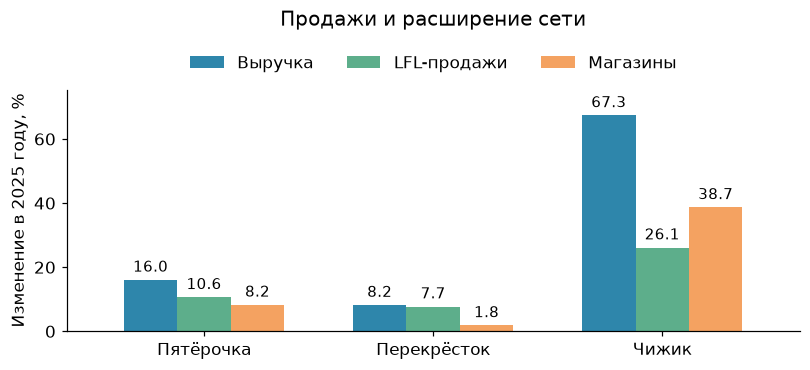

In [7]:
comparison = pd.DataFrame({
    "Выручка": growth["Рост, %"],
    "LFL-продажи": lfl["Продажи"],
    "Магазины": network["Рост магазинов, %"],
})
ax = comparison.plot(
    kind="bar", color=palette, figsize=(7.5, 3.5), rot=0, width=0.7
)
ax.set_title("Продажи и расширение сети", pad=42)
ax.set_xlabel("")
ax.set_ylabel("Изменение в 2025 году, %")
ax.set_ylim(0, comparison.max().max() + 8)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.01), ncol=3, frameon=False)
for bars in ax.containers:
    ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=10)
plt.tight_layout()
plt.show()

Быстрый рост Чижика наблюдается одновременно с расширением сети и ростом сопоставимых продаж. У Перекрёстка положительная динамика продаж сочетается с почти неизменной физической сетью.

## 5. Главные выводы, рекомендации и ограничения

**Что выяснили?**

Различия в динамике выручки сопровождаются разными темпами LFL и расширения. Пятёрочка задаёт основной масштаб, Чижик быстро растёт по обоим направлениям, а у Перекрёстка отдельного внимания требует трафик.

**Что это означает для бизнеса?**

- **Пятёрочка:** сравнить рентабельность новых и действующих магазинов.
- **Перекрёсток:** изучить снижение трафика по магазинам, регионам и категориям, прежде чем выбирать меры.
- **Чижик:** проверить экономику новых точек и устойчивость LFL при дальнейшем расширении.

**Какие ограничения есть у анализа?**

Это агрегированные данные трёх сетей за два года. Нет прибыли, цен, региональных различий и дат открытия магазинов. Связь показателей не доказывает причинность; общий рост выручки нельзя точно разложить на вклад LFL и расширения.